In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lake_ice_helpers import lake_files
from count_analysis_helpers import *
import os
import torch
from torch import nn
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch.optim as optim

In [ ]:
data_path = None #Add your path here
model_path = None
visualization_path = None
data_ip, ltbl_ice, ltbl_ice_depth, df_ice_clean = lake_files(data_path=data_path)

In [4]:
#df_ice_clean.head()

In [5]:
from sklearn.preprocessing import OneHotEncoder

def make_duration_table(df_ice_clean):
    '''
    Function creates duration data table based on cleaned lake-ice data.
    '''
    country_encoder = OneHotEncoder(sparse_output=False).fit(df_ice_clean[['country']])
    df_duration = pd.DataFrame(country_encoder.transform(df_ice_clean[['country']]),columns=country_encoder.categories_)
    num_cols = ['lat_wgs84','lon_wgs84','altitude_m','log_area_ha','depth_max_m']
    df_duration[num_cols] = df_ice_clean[num_cols].to_numpy()
    df_duration['ice_cover_duration'] = df_ice_clean['ice_cover_duration'].to_numpy()
    return df_duration

In [6]:
df_duration = make_duration_table(df_ice_clean=df_ice_clean)
df_duration.head()

,CA,FI,NO,SE,US,lat_wgs84,lon_wgs84,altitude_m,log_area_ha,depth_max_m,ice_cover_duration
0,0.0,0.0,0.0,1.0,0.0,65.510112,15.624015,439.0,7.353511,18.5,168.0
1,0.0,0.0,0.0,1.0,0.0,65.510112,15.624015,439.0,7.353511,18.5,190.0
2,0.0,0.0,0.0,1.0,0.0,65.510112,15.624015,439.0,7.353511,18.5,207.0
3,0.0,0.0,0.0,1.0,0.0,65.510112,15.624015,439.0,7.353511,18.5,183.0
4,0.0,0.0,0.0,1.0,0.0,65.510112,15.624015,439.0,7.353511,18.5,209.0


In [7]:
def minmax_scaler(df):
    '''
    MinMax-scales columns of a dataframe.
    '''
    maximum = df.max(axis=0)
    minimum = df.min(axis=0)
    diff = maximum-minimum
    return (df-minimum)/diff

In [8]:
minmax_scaler(df_duration).describe()

,CA,FI,NO,SE,US,lat_wgs84,lon_wgs84,altitude_m,log_area_ha,depth_max_m,ice_cover_duration
count,22279.000000,22279.000000,22279.000000,22279.000000,22279.000000,22279.000000,22279.000000,22279.000000,22279.000000,22279.000000,22279.000000
mean,0.082095,0.245478,0.046232,0.599892,0.026303,0.459712,0.864776,0.151606,0.517964,0.067482,0.442676
std,0.274516,0.430380,0.209992,0.489931,0.160038,0.122230,0.200400,0.118630,0.135844,0.081133,0.114841
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.419359,0.908740,0.059891,0.435013,0.024470,0.382022
50%,0.000000,0.000000,0.000000,1.000000,0.000000,0.480212,0.919365,0.111630,0.509946,0.044046,0.457865
75%,0.000000,0.000000,0.000000,1.000000,0.000000,0.530951,0.942649,0.224640,0.591466,0.091550,0.519663
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
df_duration.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22279 entries, 0 to 22278
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (CA,)                  22279 non-null  float64
 1   (FI,)                  22279 non-null  float64
 2   (NO,)                  22279 non-null  float64
 3   (SE,)                  22279 non-null  float64
 4   (US,)                  22279 non-null  float64
 5   (lat_wgs84,)           22279 non-null  float64
 6   (lon_wgs84,)           22279 non-null  float64
 7   (altitude_m,)          22279 non-null  float64
 8   (log_area_ha,)         22279 non-null  float64
 9   (depth_max_m,)         22279 non-null  float64
 10  (ice_cover_duration,)  22279 non-null  float64
dtypes: float64(11)
memory usage: 1.9 MB


In [10]:
#df_duration.to_csv(data_path+r'\df_duration_lake_data.csv')

## A custom made dataset for cleaned lake-ice dataset
* This is ment to be used for training and validation only.
* Loads data from source.
* Makes transform to data-frame before turning it into tensor.
* Final dataset is in tensor-format and send to current device.

In [11]:
class LakeIceDataset(Dataset):
    def __init__(self,data_path,device,feature_transform=None):
        self.data_path = data_path
        self.feature_transform = feature_transform
        self.duration_table = pd.read_csv(self.data_path,index_col=0)
        self.features = [col for col in self.duration_table.columns[:-1]]
        self.target = self.duration_table.columns[-1]
        if feature_transform is not None:
            self.duration_table.iloc[:,:-1] = self.feature_transform(self.duration_table.iloc[:,:-1])
        self.duration_table = torch.tensor(self.duration_table.to_numpy(),dtype=torch.float32).to(device,non_blocking=True) # last parameter to make cuda work with Dataloaders

    def __len__(self):
        return len(self.duration_table)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        X = self.duration_table[idx,:-1]
        y = self.duration_table[idx,-1]
        return X,y

In [12]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
duration_dataset = LakeIceDataset(data_path=data_path+r'\df_duration_lake_data.csv',
                                  device=device,
                                  feature_transform=minmax_scaler)

Fitting this lake-constant baseline model for full data:

In [ ]:
from torch.utils.data import DataLoader
BS = 200

# train_dataloader = DataLoader(train_set,
#                               batch_size=BS,
#                               shuffle=True,
#                               pin_memory=False,
#                               #pin_memory_device=device
#                               )

## Not necessary to create loader for validation data:
# valid_dataloader = DataLoader(validation_set,
#                               batch_size=BS,
#                               shuffle=True,
#                               )
full_dataloader = DataLoader(duration_dataset,
                              batch_size=BS,
                              shuffle=True,
                              drop_last=True,
                              pin_memory=False,
                              #pin_memory_device=device
                              )

In [22]:
#len(train_dataloader),len(valid_dataloader)
#len(train_dataloader),len(validation_set)
len(full_dataloader)

111

## Initial model
* Creates predictor for ice cover duration EV.
* Output is Linear layer followed by ReLU, which gives restriction for value range.
* Fit the model and makes predictions based on the EV-estimate.
* Estimated EV can be used as a parameter for Poisson-distribution.


In [24]:
class LakeIceBasicEV(nn.Module):
    '''
    Properties of this network
    * Creates predictor for ice cover duration EV.
    * Output is Linear layer followed by ReLU, which gives restriction for value range.
    * Fit the model and makes predictions based on the EV-estimate.
    * Estimated EV can be used as a parameter for Poisson-distribution.

    inputs:
        -   layer_sizes: A list including the amount of neurons in each layer.
            First value in this list the size of input vector.
        -   leaky_slopes: Each hidden layer has nn.LeakyReLU as activation function.
            These input parameters are used as 'negative_slope' for activation functions.

        -   Note that the requirement for input list lengths is: 
            len(leaky_slopes) = len(layer_sizes) - 1

    With these input lists you can fine tune the layer sizes and negative slopes for the network.
    '''
    def __init__(self,layer_sizes:list,leaky_slopes:list):
        super().__init__()
        
        self.layers = []
        input_size = layer_sizes[0]
        for idx in range(1,len(layer_sizes)):
            layer = nn.Linear(input_size,layer_sizes[idx])
            self.layers.append(layer)
            self.layers.append(nn.LeakyReLU(negative_slope=leaky_slopes[idx-1]))
            input_size = layer_sizes[idx]
        
        # Final layer gives outputs in log-format for Poisson model
        self.layers.append(nn.Linear(layer_sizes[-1],1))
        self.layers.append(nn.ReLU())
        # Final model:
        self.model = nn.Sequential(*self.layers)

    def forward(self,x):
        return self.model(x)

In [25]:
initial_layer_sizes = [len(duration_dataset.features),128,64,32,16]
initial_leaky_slopes = [0.2 for i in range(len(initial_layer_sizes)-1)]

initial_model = LakeIceBasicEV(layer_sizes=initial_layer_sizes,
                               leaky_slopes=initial_leaky_slopes).to(device)

In [26]:
loss_fn = nn.MSELoss()
optimizer = optim.Adam(initial_model.parameters(),lr=0.001)

In [ ]:
def train_epochs(model,
                 n_train_data,
                 n_epochs,
                 loss_fn,
                 optimizer,
                 train_dataloader,
                 validation_X=None,
                 validation_y=None):
  
  train_loss_avgs = [0] * n_epochs
  validation_loss_avgs = [0] * n_epochs
  
  for epoch in range(n_epochs):
    # Looping through batches in training mode:
    model.train()
    for X_batch, y_batch in train_dataloader:   
      n_batch = len(y_batch)
      preds = model(X_batch)
      loss = loss_fn(preds,y_batch.unsqueeze(1))
      train_loss_avgs[epoch] += loss.item()*n_batch/n_train_data # Output of loss is MSE. This gives correct weight for each batch.
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
    if (validation_X is not None) & (validation_y is not None):
      # After training, change to evaluation mode:
      model.eval()
      with torch.no_grad():
        # No loader for validation dataset. We can directly make predictions for whole validation data.
        validation_preds = model(validation_X)
        validation_loss = loss_fn(validation_preds,validation_y.unsqueeze(1))
        validation_loss_avgs[epoch] = validation_loss.item()
        
  if (validation_X is not None) & (validation_y is not None):
    return train_loss_avgs,validation_loss_avgs
  else:
    return train_loss_avgs
  

In [28]:
init_train_losses = train_epochs(model = initial_model,
                                                         n_train_data=len(df_duration), # train_set included all train data.
                                                         n_epochs=100,
                                                         loss_fn=loss_fn,
                                                         optimizer=optimizer,
                                                         train_dataloader=full_dataloader,
                                                         #validation_X=validation_X,
                                                         #validation_y=validation_y,
                                                         )

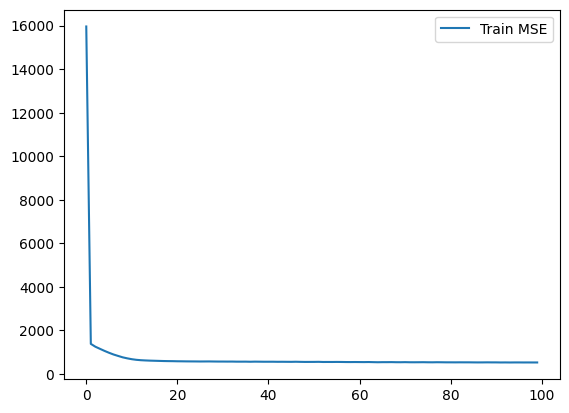

In [29]:
import matplotlib.pyplot as plt
plt.plot(init_train_losses,label='Train MSE')
#plt.plot(init_validation_losses,label='Validation MSE')
plt.legend();

In [ ]:
#torch.save(initial_model.state_dict(),model_path+'\\initial_count_model_20250415.pth')

In [31]:
initial_model.eval()
full_preds = initial_model(
                torch.tensor(minmax_scaler(df_duration.iloc[:,:-1]).to_numpy(), 
                dtype=torch.float32).to(device)
                ).cpu().detach().numpy().squeeze()

In [32]:
full_preds

array([206.82515, 206.82515, 206.82515, ..., 107.18036, 107.18036,
       107.18036], dtype=float32)

## MSE for nearly full dataset

In [33]:
mse_analysis_full_preds = short_mse_analysis(preds=full_preds,
                                            true=df_ice_clean.ice_cover_duration,
                                            return_variables=True)

MSE: 527.8349624682811
Squared error std scaled: 8.714758265761185
95% lower bound: 510.7540362673892
95% upper bound: 544.915888669173


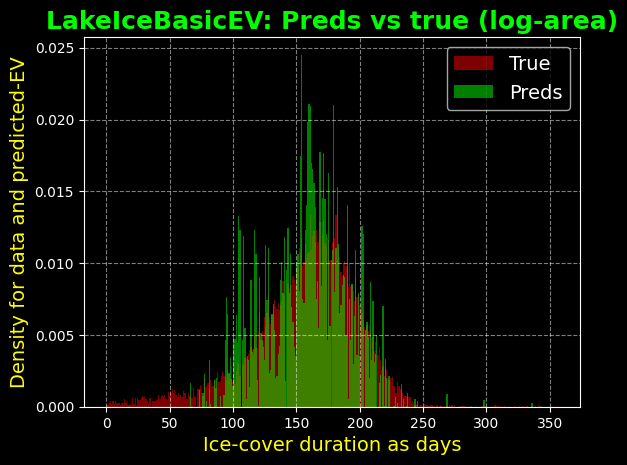

In [ ]:
preds_vs_true_distribution(model_preds=full_preds,
                                true=df_duration.ice_cover_duration,
                                titles={'title':'LakeIceBasicEV: Preds vs true (log-area)',
                                        'xlabel':'Ice-cover duration as days',
                                        'ylabel':'Density for data and predicted-EV'},
                                colors={'title':'lime',
                                        'xlabel':'yellow',
                                        'ylabel':'yellow',
                                        'preds':'lime',
                                        'true':'red'},
                                #file_path=visualization_path+'LakeIceBasicEV_preds_vs_true_log_area.png',
                                #file_path=None
                                )


In [35]:
from scipy.stats import poisson

def poisson_conditional_distribution(mu,value_vector):
    distribution = poisson.pmf(k=value_vector,mu=mu)
    return distribution/np.sum(distribution)

def LakeIceBasicEV_conditional_distributions(predictions,min_value,max_value,return_probs=False):

    value_vector = np.array([x for x in range(min_value,max_value+1)])
    probability_matrix = np.full(shape=(len(predictions),max_value-min_value+1),fill_value=np.nan)

    for idx in range(len(predictions)):
        probability_matrix[idx,:] = poisson_conditional_distribution(mu=predictions[idx],value_vector=value_vector)
        
    density_frame = pd.DataFrame(data=probability_matrix.sum(axis=0),columns=['probability_density'],index=value_vector)
    density_frame = density_frame/density_frame.sum()
    density_frame.index = density_frame.index.rename('ice_cover_duration')
    if return_probs:
        return probability_matrix,density_frame
    else:
        return density_frame


In [36]:
full_probabilities, full_probability_table = LakeIceBasicEV_conditional_distributions(
                                                                                    predictions=full_preds,
                                                                                    min_value=0,
                                                                                    max_value=365,
                                                                                    return_probs=True)

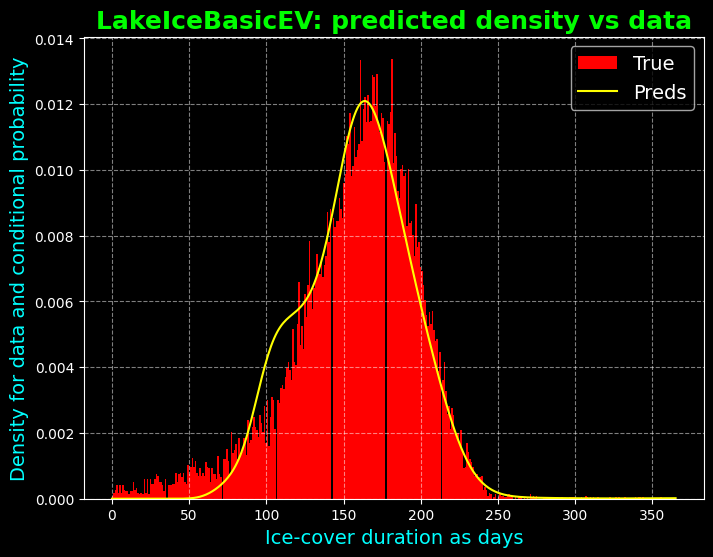

In [ ]:
colors_lakeicebasicEV = {'preds':'yellow','true':'red','title':'lime','xlabel':'cyan','ylabel':'cyan'}
titles_lakeicebasicEV = {'title':'LakeIceBasicEV: predicted density vs data','xlabel':'Ice-cover duration as days','ylabel':'Density for data and conditional probability'}

visualize_densities(prediction_density=full_probability_table,
                    true_observations=df_duration.ice_cover_duration,
                    colors=colors_lakeicebasicEV,
                    titles=titles_lakeicebasicEV,
                    #return_fig=True,
                    #file_path=visualization_path+'LakeIceBasicEV_duration_cumulated_density_vs_data_log_area.png'
                    )

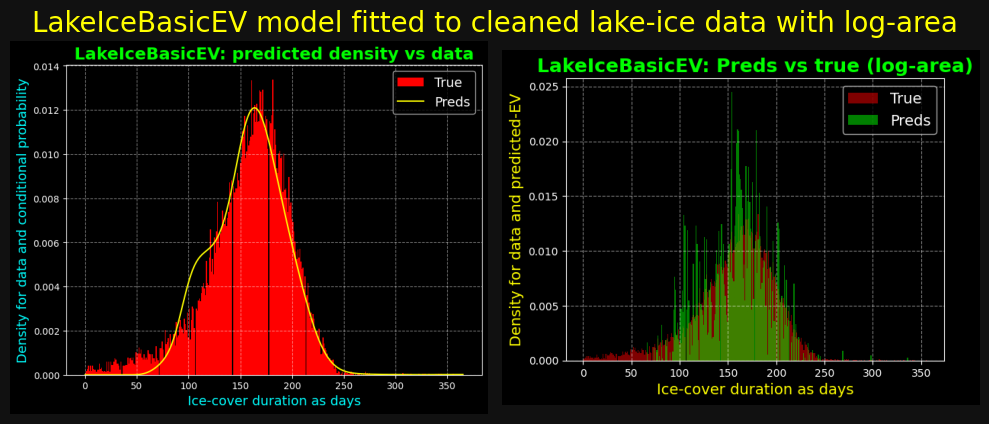

In [ ]:
density_path_LakeIceBasicEV = visualization_path+'LakeIceBasicEV_duration_cumulated_density_vs_data_log_area.png'
ev_path_LakeIceBasicEV = visualization_path+'LakeIceBasicEV_preds_vs_true_log_area.png'

combine_plot_images(density_path=density_path_LakeIceBasicEV,
                    ev_path=ev_path_LakeIceBasicEV,
                    title='LakeIceBasicEV model fitted to cleaned lake-ice data with log-area',
                    #file_path=visualization_path+'LakeIceBasicEV_combined_distribution_visualization.png',
                    )